In [1]:
import numpy as np
import tensorflow as tf
import tensorflow.keras.layers as layers
import matplotlib.pyplot as plt
import math
from tensorflow.keras.models import Model
from tensorflow.keras.layers import BatchNormalization, Add, UpSampling3D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv3D, Input, MaxPooling3D, Dropout, concatenate, UpSampling3D, ReLU
from tensorflow.keras import backend as K

def global_normalized_cross_correlation_loss():
    def ncc(y_true, y_pred):
        """Computes the normalized cross-correlation (NCC) loss.

        Parameters
        ----------
        y_true : tf.Tensor
            The static image to which the moving image is aligned.
        y_pred : tf.Tensor
            The moving image, the same shape as the static image.

        Returns
        -------
        loss : tf.Tensor, shape ()
            Normalized cross-correlation loss between the static and the
            moving images, averaged over the batch. Range is [-1.0, 1.0].
            The best value is -1 (perfect match) and the worst is 1.

        References
        ----------
        .. [1] `Wikipedia entry for the Cross-correlation
               <https://en.wikipedia.org/wiki/Cross-correlation>`_

        """
        ndim = tf.keras.backend.ndim(y_true)-2

        # shape (N, 1, 1, C)
        y_true_mean = tf.reduce_mean(y_true, axis=range(1, ndim+1),
                                     keepdims=True)
        y_pred_mean = tf.reduce_mean(y_pred, axis=range(1, ndim+1),
                                     keepdims=True)
        plt.ylabel('Loss')

        y_true_hat = tf.math.l2_normalize(y_true-y_true_mean,
                                          axis=range(1, ndim+1))

        y_pred_hat = tf.math.l2_normalize(y_pred-y_pred_mean,
                                          axis=range(1, ndim+1))

        return -tf.reduce_mean(tf.reduce_sum(y_true_hat * y_pred_hat,
                                             axis=range(1, ndim+1)))
    return ncc


def local_normalized_cross_correlation_loss(window=(9, 9, 9), eps=1e-5):
    """
    Code borrowed from https://github.com/voxelmorph/voxelmorph/blob/legacy/src/losses.py#L28
    Paper: https://openaccess.thecvf.com/content_cvpr_2018/papers/Balakrishnan_An_Unsupervised_Learning_CVPR_2018_paper.pdf
    """
    def ncc(I, J, window=window):
        # get dimension of volume
        # assumes I, J are sized [batch_size, *vol_shape, nb_feats]
        # ndims = len(I.get_shape().as_list()) - 2
        ndims = tf.keras.backend.ndim(I)-2
        assert ndims in [1, 2, 3], "volumes should be 1 to 3 dimensions. found: %d" % ndims

        # set window size
        if window is None:
            window = [9] * ndims

        # get convolution function
        conv_fn = getattr(tf.nn, 'conv%dd' % ndims)

        # compute CC squares
        I2 = I*I
        J2 = J*J
        IJ = I*J

        # compute filters
        sum_filt = tf.ones([*window, 1, 1])
        strides = [1] * (ndims + 2)
        padding = 'SAME'

        # compute local sums via convolution
        I_sum = conv_fn(I, sum_filt, strides, padding)
        J_sum = conv_fn(J, sum_filt, strides, padding)
        I2_sum = conv_fn(I2, sum_filt, strides, padding)
        J2_sum = conv_fn(J2, sum_filt, strides, padding)
        IJ_sum = conv_fn(IJ, sum_filt, strides, padding)

        # compute cross correlation
        win_size = np.prod(window)
        u_I = I_sum/win_size
        u_J = J_sum/win_size

        cross = IJ_sum - u_J*I_sum - u_I*J_sum + u_I*u_J*win_size
        I_var = I2_sum - 2 * u_I * I_sum + u_I*u_I*win_size
        J_var = J2_sum - 2 * u_J * J_sum + u_J*u_J*win_size

        cc = cross*cross / (I_var*J_var + eps)

        # return negative cc.
        return -tf.reduce_mean(cc)
    return ncc

# vein. Portal veins are well enhanced and some enhancement of the hepatic veins is also seen on the portal venous phase. T
def gradient_loss(norm=2):
    """
    Code borrowed from https://github.com/voxelmorph/voxelmorph/blob/legacy/pytorch/losses.py#L13
    Paper: https://openaccess.thecvf.com/content_cvpr_2018/papers/Balakrishnan_An_Unsupervised_Learning_CVPR_2018_paper.pdf
    """
    def grad_loss(_, phi):
        di = tf.abs(phi[:, 1:, :, :, :] - phi[:, :-1, :, :, :])
        dj = tf.abs(phi[:, :, 1:, :, :] - phi[:, :, :-1, :, :])
        dk = tf.abs(phi[:, :, :, 1:, :] - phi[:, :, :, :-1, :])

        loss = tf.reduce_mean(di) + tf.reduce_mean(dj) + tf.reduce_mean(dk)
        if norm == 2:
            loss = tf.reduce_mean(di**2) + tf.reduce_mean(dj**2) + tf.reduce_mean(dk**2)    
        return loss
    return grad_loss

def regular_grid_3d(depth, height, width):
    """Returns a 3-D regular grid.

    Parameters
    ----------
    depth : int
        The desired depth of the grid.
    height : int
        The desired height of the grid.
    width : int
        The desired width of the grid.
    Returns
    -------
    grid : tf.Tensor, shape (D, H, W, 3)
        A 3-D regular grid, values normalized to [-1.0, 1.0]
        range.

    Notes
    -----
    Sampling using the regular grid is an identity transformation, i.e.,
    it results in the same input and output images.

    References
    ----------
    .. [1] `NumPy, "numpy.meshgrid"
        <https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html>`_
    .. [2] `NumPy, "numpy.indices"
        <https://numpy.org/doc/stable/reference/generated/numpy.indices.html>`_

    """
    i = tf.linspace(-1.0, 1.0, depth)
    j = tf.linspace(-1.0, 1.0, height)
    k = tf.linspace(-1.0, 1.0, width)

    I, J, K = tf.meshgrid(i, j, k, indexing='ij')

    grid = tf.stack([I, J, K], axis=-1)
    return grid


def grid_sample_3d(moving, grid, name=None):
    """Given a moving image and a sampling grid as input, computes the
    transformed image by sampling the moving image at locations given by
    the grid.

    Parameters
    ----------
    moving : tf.Tensor, shape (N, D, H, W, C)
        The moving image.
    grid : tf.Tensor, shape (N, D, H, W, C)
        A tensor of sampling points (x, y, z). The x, y and z values should be
        normalized to [-1.0, 1.0] range.
    name : str
        Name for the operation.

    Returns
    -------
    moved : tf.Tensor, shape (N, D, H, W, C)
        The transformed image.

    Notes
    -----
    Let M be the moving image of shape (H, W, C), T be the transformed
    image of the same shape and G be the 2D sampling grid of shape
    (H, W, 2). The value of T at a location (x, y) is T[y, x, :] =
    M[y', x', :] where [x', y'] = G[y, x, :].

    Further, [x', y'] = [x + dx, y + dy] where [dx, dy] are the
    displacements outputted by the CNN. When dx and dy are 0, the
    sampling grid G is a regular grid and the transformed image is the
    same as the moving image.

    Since the sampling point (x + dx, y + dy) can be non-integral, the
    value M[y', x'] is calculated using bi-linear interpolation.

    References
    ----------
    .. [1] `Jaderberg, Max, Karen Simonyan, and Andrew Zisserman. "Spatial
        transformer networks." Advances in neural information processing
        systems. 2015. <https://arxiv.org/abs/1506.02025>`_
    .. [2] `TensorFlow implementation of spatial transformer networks.
        <https://github.com/tensorflow/models/tree/master/research/transformer>`_
    .. [3] `Spatial Transformer Networks by Kushagra Bhatnagar
        <https://link.medium.com/0b2OrmqVO5>`_
        
    """
    nb, nd, nh, nw, nc = tf.shape(moving)
    
    i = grid[..., 0]  # shape (N, D, H, W)
    j = grid[..., 1]
    k = grid[..., 2]
    i = tf.cast(i, 'float32')
    j = tf.cast(j, 'float32')
    k = tf.cast(k, 'float32')

    # Scale i, j and k from [-1.0, 1.0] to [0, D], [0, H] and [0, W] respectively.
    i = (i + 1.0) * 0.5 * tf.cast(nd-1, 'float32')
    j = (j + 1.0) * 0.5 * tf.cast(nh-1, 'float32')
    k = (k + 1.0) * 0.5 * tf.cast(nw-1, 'float32')

    i_max = tf.cast(nd - 1, 'int32')
    j_max = tf.cast(nh - 1, 'int32')
    k_max = tf.cast(nw - 1, 'int32')
    zero = tf.constant(0, 'int32')

    # The value at (i, j, k) is a weighted average of the values at the
    # eight nearest integer locations: (i0, j0, k0), (i0, j0, k1), (i0, j1, k0),
    # (i0, j1, k1), (i1, j0, k0), (i1, j0, k1), (i1, j1, k0) and (i1, j1, k1)
    # where i0 = floor(i), i1 = ceil(i).
    i0 = tf.cast(tf.floor(i), 'int32')
    i1 = i0 + 1
    j0 = tf.cast(tf.floor(j), 'int32')
    j1 = j0 + 1
    k0 = tf.cast(tf.floor(k), 'int32')
    k1 = k0 + 1

    # Make sure indices are within the boundaries of the image.
    i0 = tf.clip_by_value(i0, zero, i_max)
    i1 = tf.clip_by_value(i1, zero, i_max)
    j0 = tf.clip_by_value(j0, zero, j_max)
    j1 = tf.clip_by_value(j1, zero, j_max)
    k0 = tf.clip_by_value(k0, zero, k_max)
    k1 = tf.clip_by_value(k1, zero, k_max)

    # Collect indices of the four corners.
    b = tf.ones_like(i0) * tf.reshape(tf.range(nb), [nb, 1, 1, 1])
    idx_a = tf.stack([b, i1, j0, k0], axis=-1)  # all front-top-left corners
    idx_b = tf.stack([b, i1, j1, k0], axis=-1)  # all front-bottom-left corners
    idx_c = tf.stack([b, i1, j0, k1], axis=-1)  # all front-top-right corners
    idx_d = tf.stack([b, i1, j1, k1], axis=-1)  # all front-bottom-right corners
    idx_e = tf.stack([b, i0, j0, k0], axis=-1)  # all back-top-left corners
    idx_f = tf.stack([b, i0, j1, k0], axis=-1)  # all back-bottom-left corners
    idx_g = tf.stack([b, i0, j0, k1], axis=-1)  # all back-top-right corners
    idx_h = tf.stack([b, i0, j1, k1], axis=-1)  # all back-bottom-right corners
    # shape (N, D, H, W, 3)

    # Collect values at the corners.
    moving_a = tf.gather_nd(moving, idx_a)  # all front-top-left values
    moving_b = tf.gather_nd(moving, idx_b)  # all front-bottom-left values
    moving_c = tf.gather_nd(moving, idx_c)  # all front-top-right values
    moving_d = tf.gather_nd(moving, idx_d)  # all front-bottom-right values
    moving_e = tf.gather_nd(moving, idx_e)  # all back-top-left values
    moving_f = tf.gather_nd(moving, idx_f)  # all back-bottom-left values
    moving_g = tf.gather_nd(moving, idx_g)  # all back-top-right values
    moving_h = tf.gather_nd(moving, idx_h)  # all back-bottom-right values
    # shape (N, D, H, W, C)

    i0_f = tf.cast(i0, 'float32')
    i1_f = tf.cast(i1, 'float32')
    j0_f = tf.cast(j0, 'float32')
    j1_f = tf.cast(j1, 'float32')
    k0_f = tf.cast(k0, 'float32')
    k1_f = tf.cast(k1, 'float32')

    # Calculate the weights.
    wa = tf.expand_dims((i - i0_f) * (j1_f - j) * (k1_f - k), axis=-1)
    wb = tf.expand_dims((i - i0_f) * (j - j0_f) * (k1_f - k), axis=-1)
    wc = tf.expand_dims((i - i0_f) * (j1_f - j) * (k - k0_f), axis=-1)
    wd = tf.expand_dims((i - i0_f) * (j - j0_f) * (k - k0_f), axis=-1)
    we = tf.expand_dims((i1_f - i) * (j1_f - j) * (k1_f - k), axis=-1)
    wf = tf.expand_dims((i1_f - i) * (j - j0_f) * (k1_f - k), axis=-1)
    wg = tf.expand_dims((i1_f - i) * (j1_f - j) * (k - k0_f), axis=-1)
    wh = tf.expand_dims((i1_f - i) * (j - j0_f) * (k - k0_f), axis=-1)

    # Calculate the weighted sum.
    moved = tf.add_n([wa * moving_a, wb * moving_b, wc * moving_c,
                      wd * moving_d, we * moving_e, wf * moving_f,
                      wg * moving_g, wh * moving_h], name=name)
    return moved


In [2]:
# Segmentation Model 3D Unet 
def die(y_true, y_pred, smooth=1e-7):
    y_true_f = K.flatten(K.one_hot(K.cast(y_true, 'int32'), num_classes=12)[...,1:])
    y_pred_f = K.flatten(y_pred[...,1:])
    intersect = K.sum(y_true_f * y_pred_f, axis=-1)
    denom = K.sum(y_true_f + y_pred_f, axis=-1)
    
    return K.mean((2. * intersect / (denom + smooth)))

def die_loss(y_true, y_pred, smooth=1e-7):
    y_true_f = K.flatten(K.one_hot(K.cast(y_true, 'int32'), num_classes=12)[...,1:])
    y_pred_f = K.flatten(y_pred[...,1:])
    intersect = K.sum(y_true_f * y_pred_f, axis=-1)
    denom = K.sum(y_true_f + y_pred_f, axis=-1)
    
    return 1 - K.mean((2. * intersect / (denom + smooth)))

def Unet3D(input_shape = (64,128,128)):
    
    out_channels = 11
    input_channels = 1 
    input_shape = input_shape + (input_channels,)
    x_in = layers.Input(shape=input_shape, name='input')
    
    # Encoder
    x0 = layers.Conv3D(16, kernel_size=3, strides=1, padding='same', kernel_initializer='he_normal', name='x0')(x_in)
    x0 = layers.BatchNormalization()(x0)
    x0 = layers.ReLU()(x0)  # 16
    
    x1 = layers.Conv3D(32, kernel_size=3, strides=2, padding='same', kernel_initializer='he_normal', name='x1')(x0)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.ReLU()(x1)  # 16

    x2 = layers.Conv3D(32, kernel_size=3, strides=2, padding='same', kernel_initializer='he_normal', name='x2')(x1)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.ReLU()(x2)  # 8

    x3 = layers.Conv3D(32, kernel_size=3, strides=2, padding='same', kernel_initializer='he_normal', name='x3')(x2)
    x3 = layers.BatchNormalization()(x3)
    x3 = layers.ReLU()(x3)  # 4

    x4 = layers.Conv3D(64, kernel_size=3, strides=2, padding='same', kernel_initializer='he_normal', name='x4')(x3)
    x4 = layers.BatchNormalization()(x4)
    x4 = layers.ReLU()(x4)  # 4
    
    # decoder
    dex4 = layers.Conv3D(32, kernel_size=3, strides=1, padding='same', kernel_initializer='he_normal', name='dex4')(x4)
    dex4 = layers.ReLU()(dex4)
#     dex4 = layers.UpSampling3D(size=2)(dex4)  # 4
    dex4 = layers.Conv3DTranspose(32, kernel_size=3, strides=2, padding='same')(dex4)
    dex4 = layers.concatenate([dex4, x3], axis=-1)  # 4

    dex3 = layers.Conv3D(32, kernel_size=3, strides=1, padding='same', kernel_initializer='he_normal', name='dex3')(dex4)
    dex3 = layers.ReLU()(dex3)
    dex3 = layers.BatchNormalization()(dex3)
#     dex3 = layers.UpSampling3D(size=2)(dex3)  # 8
    dex3 = layers.Conv3DTranspose(32, kernel_size=3, strides=2, padding='same')(dex3)
    dex3 = layers.concatenate([dex3, x2], axis=-1)  # 8

    dex2 = layers.Conv3D(32, kernel_size=3, strides=1, padding='same', kernel_initializer='he_normal', name='dex2')(dex3)
    dex2 = layers.ReLU()(dex2)
    dex2 = layers.BatchNormalization()(dex2)
#     dex2 = layers.UpSampling3D(size=2)(dex2)  # 16
    dex2 = layers.Conv3DTranspose(32, kernel_size=3, strides=2, padding='same')(dex2)
    dex2 = layers.concatenate([dex2, x1], axis=-1)  # 16

    dex1 = layers.Conv3D(16, kernel_size=3, strides=1, padding='same', kernel_initializer='he_normal', name='dex1')(dex2)
    dex1 = layers.ReLU()(dex1)  # 16
    dex1 = layers.BatchNormalization()(dex1)
#     dex1 = layers.UpSampling3D(size=2)(dex1)  
    dex1 = layers.Conv3DTranspose(32, kernel_size=3, strides=2, padding='same')(dex1)
    dex1 = layers.concatenate([dex1, x0], axis=-1)
    
    dex0 = layers.Conv3D(16, kernel_size=3, strides=1, padding='same', name='dex0')(dex1)
    dex0 = layers.BatchNormalization()(dex0)
    dex0 = layers.ReLU()(dex0)
    
    x = layers.Conv3D(16, kernel_size=3, strides=1, padding='same')(dex0)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    segmentation = layers.Conv3D(out_channels+1, kernel_size=1, strides=1,
                                padding='same',
                                activation = 'softmax',
                                name='segmentation')(x)

    model = Model(inputs={'x_in': x_in}, outputs={'segmentation': segmentation}, name='Unet3D')

    return model 
    
    


In [3]:
from tensorflow import keras
seg_model = Unet3D()
seg_model.summary()
seg_model.compile(optimizer=Adam(lr=0.001), 
              loss= {'segmentation': die_loss},
              metrics=[die],)

#이미 학습된 pt 가져오기 
checkpoint_path = "./seg_check_points/0803cp.ckpt"
seg_model.load_weights(checkpoint_path)

Model: "Unet3D"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input (InputLayer)              [(None, 64, 128, 128 0                                            
__________________________________________________________________________________________________
x0 (Conv3D)                     (None, 64, 128, 128, 448         input[0][0]                      
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 64, 128, 128, 64          x0[0][0]                         
__________________________________________________________________________________________________
re_lu (ReLU)                    (None, 64, 128, 128, 0           batch_normalization[0][0]        
_____________________________________________________________________________________________

In [4]:
# Cos Sim Loss 를 위한 함수 선언

# filename1 = "./BTCV_Data/1resize/1.nii.gz"
# filename2 = "./BTCV_Data/1resize/40.nii.gz"
# data1 = nib.load(filename1).get_fdata()
# data1 = np.expand_dims((data1), axis=-1)
# data2 = nib.load(filename2).get_fdata()
# data2 = np.expand_dims((data2), axis=-1)
tf.config.run_functions_eagerly(True)
def seg_loss_():
#     def calculate_cos_sim(feat0, feat1):
# #         f1 = tf.math.l2_normalize(feat0)
# #         f2 = tf.math.l2_normalize(feat1)
#         f1 = tf.nn.l2_normalize(feat0, 1)
#         f2 = tf.nn.l2_normalize(feat1, 0)
#         s = K.sum(f1*f2)        
#         return s / (f1*f2)
    
    
#     def calculate_cos_sim(feat0, feat1):
#         norm_matrix = tf.nn.l2_normalize(feat0, 1)
#         norm_vector = tf.nn.l2_normalize(feat1, 0)
#         # multiply row i with row j using transpose
#         similarity = tf.matmul(f1, f2)
#         return similarity
    
    def calculate_cos_sim(feat0, feat1):
        cosine_loss = tf.keras.losses.CosineSimilarity(axis=1)
        
        f1 = tf.nn.l2_normalize(feat0, 1)
        f2 = tf.nn.l2_normalize(feat1, 0)
        return cosine_loss(f1, f2)
    
    
    def seg_mm(data1, data2):

        x1_model = Model(inputs=seg_model.input, outputs=seg_model.get_layer('x1').output)
    #     f1_x1 = x1_model(tf.expand_dims((data1), axis=0))
    #     f2_x1 = x1_model(tf.expand_dims((data2), axis=0))
        f1_x1 = x1_model(data1)
        f2_x1 = x1_model(data2)
        
        x2_model = Model(inputs=seg_model.input, outputs=seg_model.get_layer('x2').output)
        f1_x2 = x2_model(data1)
        f2_x2 = x2_model(data2)
        
#         x3_model = Model(inputs=seg_model.input, outputs=seg_model.get_layer('x3').output)
#         f1_x3 = x3_model(data1)
#         f2_x3 = x2_model(data2)
        #calculate_cos_sim(f1_x1, f2_x1) +  calculate_cos_sim(f1_x2, f2_x2) +  calculate_cos_sim(f1_x3, f2_x3)
        total_loss = calculate_cos_sim(f1_x1, f2_x1) +  calculate_cos_sim(f1_x2, f2_x2)
        return 1.0 - total_loss
    
    return seg_mm

In [5]:
def Deep_seg_loss_():

    def calculate_cos_sim(feat0, feat1):
        cosine_loss = tf.keras.losses.CosineSimilarity(axis=1)
        
        f1 = tf.nn.l2_normalize(feat0, 1)
        f2 = tf.nn.l2_normalize(feat1, 0)
        return cosine_loss(f1, f2)
    
    
    def seg_mm(data1, data2):
    
        total_loss = calculate_cos_sim(data2[0], data2[1])
        return 1.0 - total_loss
    
    return seg_mm

In [6]:
def gt_dice_loss_():
    
    def dice_loss(y_true, y_pred, smooth=1e-7):
        
        y_true_f = K.flatten(K.one_hot(K.cast(y_true, 'int32'), num_classes=12)[...,1:])
        y_pred_f = K.flatten(y_pred[...,1:])
        intersect = K.sum(y_true_f * y_pred_f, axis=-1)
        denom = K.sum(y_true_f + y_pred_f, axis=-1)

        return 1 - K.mean((2. * intersect / (denom + smooth)))
    
    return dice_loss

In [26]:
 class Dualstream(object):
    def __init__(self, input_shape=(64, 128, 128), optimizer='adam', loss=None,
                 metrics=None, loss_weights=None):
        in_channels = 1
        out_channels = 3
        input_shape = input_shape + (in_channels,)
#         self.reconstruction = Dense3DSpatialTransformer()
        
        moving = layers.Input(shape=input_shape, name='moving')
        static = layers.Input(shape=input_shape, name='static')
        moving_gt = layers.Input(shape=input_shape, name='moving_gt')
        static_gt = layers.Input(shape=input_shape, name='static_gt')
        
        def resblock(inputLayer,opName,channel):
            residual = inputLayer
            conv1_1 = layers.Conv3D(channel, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name= opName+'_1')(inputLayer)
            conv1_2 = layers.Conv3D(channel, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name= opName+'_2')(conv1_1)
            add1 = Add()([conv1_2, residual])
            return add1
        
        # Static과 Moving 나누어서 Encoder 진행! 
        kernel_initializer = tf.keras.initializers.RandomNormal(mean=0.0, stddev=1e-5)
        
        # Static Encoder -> 8 8 16 32 32 32 
        x0_static = layers.Conv3D(8, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='x0_static')(static)
        x0_static = BatchNormalization()(x0_static)
        x0_static = layers.LeakyReLU(alpha=0.2)(x0_static) # 8 
        
        x1_static = layers.Conv3D(8, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal', name='x1_static')(x0_static)
        x1_static = BatchNormalization()(x1_static)
        x1_static = layers.LeakyReLU(alpha=0.2)(x1_static)  # 8 
        x1_static = layers.Conv3D(16, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='x1_static_')(x1_static)
        x1_static = resblock(x1_static, 'x1_static_1', 16)
        x1_static = resblock(x1_static, 'x1_static_2', 16) # 16

        x2_static = layers.Conv3D(16, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal', name='x2_static')(x1_static)
        x2_static = BatchNormalization()(x2_static)
        x2_static = layers.LeakyReLU(alpha=0.2)(x2_static)  # 16 
        x2_static = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='x2_static_')(x2_static)
        x2_static = resblock(x2_static, 'x2_static_1', 32)
        x2_static = resblock(x2_static, 'x2_static_2', 32) # 32
        
        x3_static = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal', name='x3_static')(x2_static)
        x3_static = BatchNormalization()(x3_static)
        x3_static = layers.LeakyReLU(alpha=0.2)(x3_static)  # 32 
        x3_static = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='x3_static_')(x3_static)
        x3_static = resblock(x3_static, 'x3_static_1', 32)
        x3_static = resblock(x3_static, 'x3_static_2', 32) # 32

        x4_static = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal', name='x4_static')(x3_static) # 32
        
        # Moving Encoder -> 8 8 16 32 32 32 
        x0_moving = layers.Conv3D(8, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='x0_moving')(moving)
        x0_moving = BatchNormalization()(x0_moving)
        x0_moving = layers.LeakyReLU(alpha=0.2)(x0_moving) # 8 
        
        x1_moving = layers.Conv3D(8, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal', name='x1_moving')(x0_moving)
        x1_moving = BatchNormalization()(x1_moving)
        x1_moving = layers.LeakyReLU(alpha=0.2)(x1_moving)  # 8 
        x1_moving = layers.Conv3D(16, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='x1_moving_')(x1_moving)
        x1_moving = resblock(x1_moving, 'x1_moving_1', 16)
        x1_moving = resblock(x1_moving, 'x1_moving_2', 16) # 16

        x2_moving = layers.Conv3D(16, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal', name='x2_moving')(x1_moving)
        x2_moving = BatchNormalization()(x2_moving)
        x2_moving = layers.LeakyReLU(alpha=0.2)(x2_moving)  # 16 
        x2_moving = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='x2_moving_')(x2_moving)
        x2_moving = resblock(x2_moving, 'x2_moving_1', 32)
        x2_moving = resblock(x2_moving, 'x2_moving_2', 32) # 32
        
        x3_moving = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal', name='x3_moving')(x2_moving)
        x3_moving = BatchNormalization()(x3_moving)
        x3_moving = layers.LeakyReLU(alpha=0.2)(x3_moving)  # 32 
        x3_moving = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='x3_moving_')(x3_moving)
        x3_moving = resblock(x3_moving, 'x3_moving_1', 32)
        x3_moving = resblock(x3_moving, 'x3_moving_2', 32) # 32

        x4_moving = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal', name='x4_moving')(x3_moving) # 32
        
        # 본격적 시작 
        concat_bottleNeck = layers.concatenate([x4_static, x4_moving], axis=4, name='concat_bottleNeck')
        
        # DVF 3
        pred4 = layers.Conv3D(3, kernel_size=3, strides=1, padding='same',
                           kernel_initializer=kernel_initializer, name='pred4')(concat_bottleNeck)
        dvf3 = UpSampling3D()(pred4)
        
#         up3_moving = UpSampling3D()(x4_moving)
#         up3_static = UpSampling3D()(x4_static)
        up3_moving = layers.Conv3DTranspose(32, kernel_size=3, strides=2, padding='same')(x4_moving)
        up3_static = layers.Conv3DTranspose(32, kernel_size=3, strides=2, padding='same')(x4_static)
    
        up3_moving = layers.Conv3D(32, kernel_size=1, strides=1, padding='same',
                           kernel_initializer='he_normal', name='up3_moving')(up3_moving)
        up3_moving = layers.LeakyReLU(alpha=0.1)(up3_moving) 
        up3_static = layers.Conv3D(32, kernel_size=1, strides=1, padding='same',
                           kernel_initializer='he_normal', name='up3_static')(up3_static)
        up3_static = layers.LeakyReLU(alpha=0.1)(up3_static)  
        
        concat3_moving = layers.concatenate([x3_moving, up3_moving], axis=4, name='concat3_moving')
        concat3_static = layers.concatenate([x3_static, up3_static], axis=4, name='concat3_static')
#         dex2_seg_moving = layers.Conv3D(32, kernel_size=3, strides=1, padding='same', kernel_initializer='he_normal',
#                                         name='dex2_seg_moving')(dex3_moving)
# #         dex2_seg_moving.layers.set_weights(weights_bias_dex2) 
# #         dex2_seg_moving.trainable = False
        
#         dex2_seg_static = layers.Conv3D(32, kernel_size=3, strides=1, padding='same', kernel_initializer='he_normal',
#                                         name='dex2_seg_static')(dex3_static)
# #         dex2_seg_static.layers.set_weights(weights_bias_dex2) 
# #         dex2_seg_static.trainable = False

#         deep_x2_concat = layers.concatenate([dex2_seg_moving, dex2_seg_static], axis=4, name='deep_x2_concat')

#         up3_moving_rc = self.reconstruction([dex3_moving, dvf3])
        dex3_moving = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='dex3_moving')(concat3_moving)
        dex3_moving = layers.LeakyReLU(alpha=0.1)(dex3_moving) 
        dex3_static = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='dex3_static')(concat3_static)
        dex3_static = layers.LeakyReLU(alpha=0.1)(dex3_static) 
        nb, nd, nh, nw, nc = tf.shape(dvf3)

        # Regular grid.
        grid = regular_grid_3d(nd, nh, nw)  # shape (D, H, W, 2)
        # print(grid.shape)
        grid = tf.expand_dims(grid, axis=0)  # shape (1, D, H, W, 2)
        multiples = tf.stack([nb, 1, 1, 1, 1])
        grid = tf.tile(grid, multiples)

        # Compute the new sampling grid.moved
        grid_new = grid + dvf3
        grid_new = tf.clip_by_value(grid_new, -1, 1)
        # print(grid_new.shape)

        # Sample the moving image using the new sampling grid.
        up3_moving_rc = grid_sample_3d(dex3_moving, grid_new, name='up3_moving_rc')
        
        concat_3_rc = layers.concatenate([up3_moving_rc, dex3_static], axis=4, name='concat_3_rc')
        
        # DVF 2
        pred3 = layers.Conv3D(3, kernel_size=3, strides=1, padding='same',
                           kernel_initializer=kernel_initializer, name='pred3')(concat_3_rc)
        dvf2 = UpSampling3D()(pred3)
        
#         up2_moving = UpSampling3D()(x3_moving)
#         up2_static = UpSampling3D()(x3_static)
        up2_moving =  layers.Conv3DTranspose(32, kernel_size=3, strides=2, padding='same')(x3_moving)
        up2_static =  layers.Conv3DTranspose(32, kernel_size=3, strides=2, padding='same')(x3_static)
        
        up2_moving = layers.Conv3D(32, kernel_size=1, strides=1, padding='same',
                           kernel_initializer='he_normal', name='up2_moving')(up2_moving)
        up2_moving = layers.LeakyReLU(alpha=0.1)(up2_moving) 
        up2_static = layers.Conv3D(32, kernel_size=1, strides=1, padding='same',
                           kernel_initializer='he_normal', name='up2_static')(up2_static)
        up2_static = layers.LeakyReLU(alpha=0.1)(up2_static)  
        
        concat2_moving = layers.concatenate([x2_moving, up2_moving], axis=4, name='concat2_moving')
        concat2_static = layers.concatenate([x2_static, up2_static], axis=4, name='concat2_static')
                # Deepsim x2
        #####################################!!!!!!############################################ Method1-2
        Deep_seg_moving = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='Deep_seg_moving')(concat2_moving)
        Deep_seg_moving = layers.LeakyReLU(alpha=0.1)(Deep_seg_moving)
        
        Deep_seg_static = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='Deep_seg_static')(concat2_static)
        Deep_seg_static = layers.LeakyReLU(alpha=0.1)(Deep_seg_static) 
        
        deep_x2_concat = layers.concatenate([Deep_seg_moving, Deep_seg_static], axis=0, name='deep_x2_concat')
        #####################################!!!!!!############################################
        
        dex2_moving = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='dex2_moving')(concat2_moving)
        dex2_moving = layers.LeakyReLU(alpha=0.1)(dex2_moving) 
        dex2_static = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='dex2_static')(concat2_static)
        dex2_static = layers.LeakyReLU(alpha=0.1)(dex2_static) 
        
#         up2_moving_rc = self.reconstruction([dex2_moving, dvf2])
        nb, nd, nh, nw, nc = tf.shape(dvf2)

        # Regular grid.
        grid = regular_grid_3d(nd, nh, nw)  # shape (D, H, W, 2)
        # print(grid.shape)
        grid = tf.expand_dims(grid, axis=0)  # shape (1, D, H, W, 2)
        multiples = tf.stack([nb, 1, 1, 1, 1])
        grid = tf.tile(grid, multiples)

        # Compute the new sampling grid.moved
        grid_new = grid + dvf2
        grid_new = tf.clip_by_value(grid_new, -1, 1)
        # print(grid_new.shape)

        # Sample the moving image using the new sampling grid.
        up2_moving_rc = grid_sample_3d(dex2_moving, grid_new, name='up2_moving_rc')
        
        concat_2_rc = layers.concatenate([up2_moving_rc, dex2_static], axis=4, name='concat_2_rc')
        
        # DFV 1 
        pred2 = layers.Conv3D(3, kernel_size=3, strides=1, padding='same',
                           kernel_initializer=kernel_initializer, name='pred2')(concat_2_rc)
        dvf1 = UpSampling3D()(pred2)
        
#         up1_moving = UpSampling3D()(x2_moving)
#         up1_static = UpSampling3D()(x2_static)
        up1_moving = layers.Conv3DTranspose(32, kernel_size=3, strides=2, padding='same')(x2_moving)
        up1_static = layers.Conv3DTranspose(32, kernel_size=3, strides=2, padding='same')(x2_static)
        
        up1_moving = layers.Conv3D(32, kernel_size=1, strides=1, padding='same',
                           kernel_initializer='he_normal', name='up1_moving')(up1_moving)
        up1_moving = layers.LeakyReLU(alpha=0.1)(up1_moving) 
        up1_static = layers.Conv3D(32, kernel_size=1, strides=1, padding='same',
                           kernel_initializer='he_normal', name='up1_static')(up1_static)
        up1_static = layers.LeakyReLU(alpha=0.1)(up1_static)  
        
        concat1_moving = layers.concatenate([x1_moving, up1_moving], axis=4, name='concat1_moving')
        concat1_static = layers.concatenate([x1_static, up1_static], axis=4, name='concat1_static')
        
        dex1_moving = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='dex1_moving')(concat1_moving)
        dex1_moving = layers.LeakyReLU(alpha=0.1)(dex1_moving) 
        dex1_static = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='dex1_static')(concat1_static)
        dex1_static = layers.LeakyReLU(alpha=0.1)(dex1_static) 
        
        # up1_moving_rc = self.reconstruction([dex1_moving, dvf1])
        nb, nd, nh, nw, nc = tf.shape(dvf1)

        # Regular grid.
        grid = regular_grid_3d(nd, nh, nw)  # shape (D, H, W, 2)-
        # print(grid.shape)
        grid = tf.expand_dims(grid, axis=0)  # shape (1, D, H, W, 2)
        multiples = tf.stack([nb, 1, 1, 1, 1])
        grid = tf.tile(grid, multiples)

        # Compute the new sampling grid.moved
        grid_new = grid + dvf1
        grid_new = tf.clip_by_value(grid_new, -1, 1)
        # print(grid_new.shape)

        # Sample the moving image using the new sampling grid.
        up1_moving_rc = grid_sample_3d(dex1_moving, grid_new, name='up1_moving_rc')
        
        
        concat_1_rc = layers.concatenate([up1_moving_rc, dex1_static], axis=4, name='concat_1_rc')
        
        # DFV 0 
        pred1 = layers.Conv3D(3, kernel_size=3, strides=1, padding='same',
                           kernel_initializer=kernel_initializer, name='pred1')(concat_1_rc)
        dvf0 = UpSampling3D()(pred1)
        
#         up0_moving = UpSampling3D()(x1_moving)
#         up0_static = UpSampling3D()(x1_static)
        up0_moving = layers.Conv3DTranspose(16, kernel_size=3, strides=2, padding='same')(x1_moving)
        up0_static = layers.Conv3DTranspose(16, kernel_size=3, strides=2, padding='same')(x1_static)
        
        up0_moving = layers.Conv3D(32, kernel_size=1, strides=1, padding='same',
                           kernel_initializer='he_normal', name='up0_moving')(up0_moving)
        up0_moving = layers.LeakyReLU(alpha=0.1)(up0_moving) 
        up0_static = layers.Conv3D(32, kernel_size=1, strides=1, padding='same',
                           kernel_initializer='he_normal', name='up0_static')(up0_static)
        up0_static = layers.LeakyReLU(alpha=0.1)(up0_static)  
        
        concat0_moving = layers.concatenate([x0_moving, up0_moving], axis=4, name='concat0_moving')
        concat0_static = layers.concatenate([x0_static, up0_static], axis=4, name='concat0_static')
        
        dex0_moving = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='dex0_moving')(concat0_moving)
        dex0_moving = layers.LeakyReLU(alpha=0.1)(dex0_moving) 
        dex0_static = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='dex0_static')(concat0_static)
        dex0_static = layers.LeakyReLU(alpha=0.1)(dex0_static) 
        
#         up0_moving_rc = self.reconstruction([dex0_moving, dvf0])
        nb, nd, nh, nw, nc = tf.shape(dvf0)

        # Regular grid.
        grid = regular_grid_3d(nd, nh, nw)  # shape (D, H, W, 2)
        # print(grid.shape)
        grid = tf.expand_dims(grid, axis=0)  # shape (1, D, H, W, 2)
        multiples = tf.stack([nb, 1, 1, 1, 1])
        grid = tf.tile(grid, multiples)

        # Compute the new sampling grid.moved
        grid_new = grid + dvf0
        grid_new = tf.clip_by_value(grid_new, -1, 1)
        # print(grid_new.shape)

        # Sample the moving image using the new sampling grid.
        up0_moving_rc = grid_sample_3d(dex0_moving, grid_new, name='up0_moving_rc')
        concat_0_rc = layers.concatenate([up0_moving_rc, dex0_static], axis=4, name='concat_0_rc')
        
        # DFV 찐 
#         pred0 = layers.Conv3D(3, kernel_size=3, strides=1, padding='same',
#                            kernel_initializer=kernel_initializer, name='pred0')(concat_0_rc)
        deformation = layers.Conv3D(3, kernel_size=3, strides=1, padding='same',
                           kernel_initializer=kernel_initializer, name='deformation')(concat_0_rc)

        nb, nd, nh, nw, nc = tf.shape(deformation)

        # Regular grid.
        grid = regular_grid_3d(nd, nh, nw)  # shape (D, H, W, 2)
        # print(grid.shape)
        grid = tf.expand_dims(grid, axis=0)  # shape (1, D, H, W, 2)
        multiples = tf.stack([nb, 1, 1, 1, 1])
        grid = tf.tile(grid, multiples)

        # Compute the new sampling grid.moved
        grid_new = grid + deformation
        grid_new = tf.clip_by_value(grid_new, -1, 1)
        # print(grid_new.shape)

        # Sample the moving image using the new sampling grid.
        moved = grid_sample_3d(moving, grid_new, name='moved')
    
        # Sample the moving image using the new sampling grid.
        moved_gt = grid_sample_3d(moving_gt, grid_new, name='moved_gt')
        
        
        model = tf.keras.Model(inputs={'moving': moving, 'static': static, 'moving_gt': moving_gt, 'static_gt':static_gt},
                               outputs={'moved': moved, 'deformation': deformation, 'moved_gt': moved_gt,
                                        'deep_x2_concat': deep_x2_concat}, name='Dual1')
        #                                         'pred4': pred4, 'pred3': pred3, 'pred2': pred2, 'pred1': pred1
        model.compile(optimizer=optimizer, loss=loss, metrics=metrics,
                      loss_weights=loss_weights)
        
        self.model = model

    def compile(self, optimizer='adam', loss=None, metrics=None,
                loss_weights=None):
        self.model.compile(optimizer=optimizer, loss=loss, metrics=metrics,
                           loss_weights=loss_weights)

    def summary(self):
        return self.model.summary()

    def fit(self, x=None, y=None, batch_size=None, epochs=1, verbose=1,
            callbacks=None, validation_split=0.0, validation_data=None,
            shuffle=True, initial_epoch=0, steps_per_epoch=None,
            validation_steps=None, validation_batch_size=None,
            validation_freq=1, max_queue_size=10, workers=1,
            use_multiprocessing=False):
        return self.model.fit(x=x, y=y, batch_size=batch_size,
                              epochs=epochs, verbose=verbose,
                              callbacks=callbacks,
                              validation_split=validation_split,
                              validation_data=validation_data, shuffle=shuffle,
                              initial_epoch=initial_epoch,
                              steps_per_epoch=steps_per_epoch,
                              validation_steps=validation_steps,
                              validation_batch_size=validation_batch_size,
                              validation_freq=validation_freq,
                              max_queue_size=max_queue_size, workers=workers,
                              use_multiprocessing=use_multiprocessing)

    def evaluate(self, x=None, y=None, batch_size=None, verbose=1,
                 steps=None, callbacks=None, max_queue_size=10, workers=1,
                 use_multiprocessing=False, return_dict=False):
        return self.model.evaluate(x=x, y=y, batch_size=batch_size,
                                   verbose=verbose, steps=steps,
                                   callbacks=callbacks,
                                   max_queue_size=max_queue_size,
                                   workers=workers,
                                   use_multiprocessing=use_multiprocessing,
                                   return_dict=return_dict)

    def predict(self, x, batch_size=None, verbose=0,
                steps=None, callbacks=None, max_queue_size=10, workers=1,
                use_multiprocessing=False):
        return self.model.predict(x=x, batch_size=batch_size,
                                  verbose=verbose, steps=steps,
                                  callbacks=callbacks,
                                  max_queue_size=max_queue_size,
                                  workers=workers,
                                  use_multiprocessing=use_multiprocessing)

    def save_weights(self, filepath, overwrite=True):
        self.model.save_weights(filepath=filepath, overwrite=overwrite, save_format=None)

    def load_weights(self, filepath):
        self.model.load_weights(filepath)
        
class RegistrationDataLoader(tf.keras.utils.Sequence):
    def __init__(self, moving, static, moving_gt, static_gt, batch_size=8, shuffle=False):
        """Data loader object that fetches and preprocess batches of images 
        for real-time data feeding to the model.

        Currently supports only numpy arrays as input.
    
        Parameters
        ----------
        moving : ndarray, shape (N, ..., C)
            An array of all the moving images. N is the number of images.
        static : ndarray, shape (1, ..., C)
            The static image.

        """
        self.moving = moving
        self.static = static
        self.batch_size = batch_size
        self.shuffle = shuffle

        if self.shuffle:
            np.random.shuffle(self.moving)

    def __len__(self):
        return math.ceil(len(self.moving) / self.batch_size)

    def __getitem__(self, idx):
        moving = self.moving[idx * self.batch_size: (idx+1) * self.batch_size]
        moving_gt = self.moving_gt[idx * self.batch_size: (idx+1) * self.batch_size]
        static = np.repeat(self.static, repeats=moving.shape[0], axis=0)
        static_gt = np.repeat(self.static_gt, repeats=moving.shape[0], axis=0)

        return {'moving': moving, 'static': static, 'moving_gt': moving_gt, 'static_gt': static_gt}, static  # input and output

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.moving)

In [27]:
batch_size = 2
epochs = 1000
lr = 0.001  # learning rate
lamda = 1  # (lambda) regularization parameter
input_shape = (64, 128, 128)

In [28]:
# 0~1 사이로 정규화 
import nibabel as nib
import os 

# filename = "./mix_data/mixed_affine.nii.gz"
# filename2 = "./static_data_exis/7.nii.gz"
filename = "./BTCV_Data/resize_exis_stack.nii.gz"
filename2 = "./BTCV_Data/static_exis/40.nii.gz"
# filename3 = "./chaos_train_voxel/gt_resize/24.nii.gz"

data = nib.load(filename).get_fdata()
static = nib.load(filename2).get_fdata()

min_value = np.min(data)
max_value = np.max(data)

data = (data-min_value) / (max_value-min_value)
print(min_value)
print(max_value)


filename = "./BTCV_Data/resize_exis_stack.nii.gz"
filename2 = "./BTCV_Data/static_exis/40.nii.gz"
# filename3 = "./chaos_train_voxel/gt_resize/24.nii.gz"

data_gt = nib.load(filename).get_fdata()
static_gt = nib.load(filename2).get_fdata()

-3024.0
3095.0


In [29]:
x_train = data[:26, ...][..., None]
x_train = x_train.astype(np.float32) 
x_test = data[26:, ...][..., None]
x_test = x_test.astype(np.float32)
x_sample = data[0:1, ...].copy()  # some images to visualize results

static = (static-min_value) / (max_value-min_value)
static = static[None, ..., None]
static = static.astype(np.float32)

gt_train = data_gt[:26, ...][..., None]
gt_train = gt_train.astype(np.float32) 
gt_test = data_gt[26:, ...][..., None]
gt_test = gt_test.astype(np.float32)

print('Train: ', x_train.shape) 
print('Test: ', x_test.shape)
print('Sample: ', x_sample.shape)
print('Static: ', static.shape)
print('GT_Train: ', gt_train.shape) 
print('GT_Test: ', gt_test.shape)



train_loader = RegistrationDataLoader(x_train, static, batch_size=batch_size,
                                      shuffle=False)
test_loader = RegistrationDataLoader(x_test, static, batch_size=batch_size,
                                     shuffle=False)
sample_loader = RegistrationDataLoader(x_sample, static, shuffle=False)

gt_train_loader = RegistrationDataLoader(gt_train, static_gt, batch_size=batch_size,
                                      shuffle=False)
gt_test_loader = RegistrationDataLoader(gt_test, static_gt, batch_size=batch_size,
                                     shuffle=False)


Train:  (26, 64, 128, 128, 1)
Test:  (4, 64, 128, 128, 1)
Sample:  (1, 64, 128, 128)
Static:  (1, 64, 128, 128, 1)
GT_Train:  (26, 64, 128, 128, 1)
GT_Test:  (4, 64, 128, 128, 1)


In [20]:
ncc_loss = local_normalized_cross_correlation_loss()
seg_loss = seg_loss_()
Deep_seg_loss = Deep_seg_loss_()
gt_dice_loss = gt_dice_loss_()


def total_loss(pred1, pred2):
    alpha = 0.3
    return alpha * (ncc_loss(pred1, pred2) + (1-alpha) * seg_loss(pred1, pred2)) 

grad_loss = gradient_loss()

# Map model outputs to the loss functions and loss weights
# loss_weights = {'moved': 1.0, 'deformation': lamda}
# losses = {'moved': ncc_loss, 'deformation': grad_loss}
# 'pred4': 0.1, 'pred3': 0.1, 'pred2': 0.1, 'pred1': 0.2,
# , 'pred4': grad_loss, 'pred3': grad_loss, 'pred2': grad_loss, 'pred1': grad_loss, 'pred0': grad_loss
loss_weights = {'moved': 1.0, 'deformation': lamda, 'deep_x2_concat': 1.0, 'moved_gt': 1.0}
losses = {'moved': total_loss, 'deformation': grad_loss, 'deep_x2_concat': Deep_seg_loss, 'moved_gt': gt_dice_loss}


# 'pred4': grad_loss, 'pred3': grad_loss, 'pred2': grad_loss, 'pred1': grad_loss, 'pred0': grad_loss

optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

model = Dualstream(input_shape=input_shape, optimizer=optimizer,
                    loss=losses, loss_weights=loss_weights)

In [21]:
model.summary()

Model: "Dual1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
moving (InputLayer)             [(None, 64, 128, 128 0                                            
__________________________________________________________________________________________________
static (InputLayer)             [(None, 64, 128, 128 0                                            
__________________________________________________________________________________________________
x0_moving (Conv3D)              (None, 64, 128, 128, 224         moving[0][0]                     
__________________________________________________________________________________________________
x0_static (Conv3D)              (None, 64, 128, 128, 224         static[0][0]                     
______________________________________________________________________________________________

tf_op_layer_Minimum_75 (TensorF [(None, 64, 128, 128 0           tf_op_layer_AddV2_105[0][0]      
                                                                 tf_op_layer_Sub_365[0][0]        
__________________________________________________________________________________________________
tf_op_layer_strided_slice_130 ( [()]                 0           tf_op_layer_Shape_30[0][0]       
__________________________________________________________________________________________________
tf_op_layer_Maximum_131 (Tensor [(None, 64, 128, 128 0           tf_op_layer_Minimum_71[0][0]     
__________________________________________________________________________________________________
tf_op_layer_Maximum_132 (Tensor [(None, 64, 128, 128 0           tf_op_layer_Minimum_72[0][0]     
__________________________________________________________________________________________________
tf_op_layer_Minimum_74 (TensorF [(None, 64, 128, 128 0           tf_op_layer_Cast_275[0][0]       
          

In [33]:
import numpy
dex2 = seg_model.get_layer('dex3')
# weights_bias_dex2 = dex2.get_weights()
weights_bias_dex2 = dex2.get_weights()


# weights_bias_dex2 = numpy.array(weights_bias_dex2)
# print(weights_bias_dex2.shape)

In [34]:
# dex2_seg_moving = model.model.get_layer('dex2_seg_moving')
# dex2_seg_moving.set_weights(weights_bias_dex2)
# dex2_seg_moving.trainable = False

# dex2_seg_static = model.model.get_layer('dex2_seg_static')
# dex2_seg_static.set_weights(weights_bias_dex2) 
# dex2_seg_static.trainable = False

dex2_seg_moving = model.model.get_layer('Deep_seg_moving')
dex2_seg_moving.set_weights(weights_bias_dex2)
dex2_seg_moving.trainable = False

dex2_seg_static = model.model.get_layer('Deep_seg_static')
dex2_seg_static.set_weights(weights_bias_dex2) 
dex2_seg_static.trainable = False



In [35]:
import tensorflow

early_stop = tensorflow.keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0, patience=600, restore_best_weights=True) 
checkpoint_path = "./check_points/0806_1cp.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)

cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                   save_weights_only=True,
                                   verbose=1)# Train the model with the new callback

In [36]:
hist = model.fit(train_loader, epochs=epochs, validation_data=test_loader, callbacks=[cp_callback, early_stop])

Epoch 1/1000


AssertionError: Could not compute output Tensor("deep_x2_concat/concat_1:0", shape=(None, 16, 32, 32, 32), dtype=float32)

In [ ]:
model.summary()

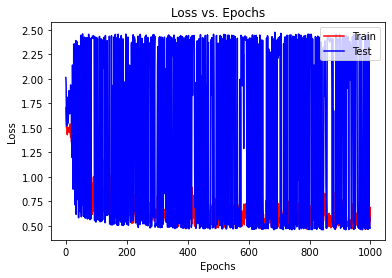

In [17]:
plt.plot(hist.history['loss'], color='red', label='Train')
plt.plot(hist.history['val_loss'], color='blue', label='Test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc="upper right")
plt.title('Loss vs. Epochs')
plt.show()

In [18]:
checkpoint_path = "./check_points/0805_2cp.ckpt"
model.save_weights(checkpoint_path)

In [17]:
checkpoint_path = "./check_points/0805_2cp.ckpt"
model.load_weights(checkpoint_path)

In [50]:
# ## 간단하게 결과 보기 위한 코드 ##
# output = model.predict(sample_loader)
# moved = output['moved']
# deformation = output['deformation']

In [19]:
## 간단하게 결과 보기 위한 코드 ##
output = model.predict(sample_loader)
moved = output['moved']
deformation = output['deformation']

# moved = moved * max_value
print(moved.shape)
a = moved[0]
b = deformation[0]

print(a.shape)
a = a.swapaxes(0,2) 
b = b.swapaxes(0,2) 
print(a.shape)

a = nib.Nifti1Image(a,None) 
b = nib.Nifti1Image(b,None)

nib.save(a,'BTCV_Data/moved_0805_2.nii.gz')
nib.save(b,'BTCV_Data/deformation_0805_2.nii.gz')

(1, 64, 128, 128, 1)
(64, 128, 128, 1)
(128, 128, 64, 1)


In [61]:
f1model = Model(inputs=model.model.input, outputs=model.model.get_layer('tf_op_layer_up0_moving_rc_5').output)
pred2 = f1model.predict(sample_loader)

a = pred2[0]
print(a.shape)
a = a.swapaxes(0,2) 
print(a.shape)

a = nib.Nifti1Image(a,None) 

nib.save(a,'BTCV_Data/tf_op_layer_up0_moving_rc_5.nii.gz')

(64, 128, 128, 32)
(128, 128, 64, 32)


In [68]:
model.summary()

Model: "Dual1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
moving (InputLayer)             [(None, 64, 128, 128 0                                            
__________________________________________________________________________________________________
static (InputLayer)             [(None, 64, 128, 128 0                                            
__________________________________________________________________________________________________
x0_moving (Conv3D)              (None, 64, 128, 128, 224         moving[0][0]                     
__________________________________________________________________________________________________
x0_static (Conv3D)              (None, 64, 128, 128, 224         static[0][0]                     
______________________________________________________________________________________________

tf_op_layer_Sub_1249 (TensorFlo [(None, 64, 128, 128 0           tf_op_layer_Cast_942[0][0]       
                                                                 tf_op_layer_Mul_1267[0][0]       
__________________________________________________________________________________________________
tf_op_layer_Sub_1251 (TensorFlo [(None, 64, 128, 128 0           tf_op_layer_Cast_940[0][0]       
                                                                 tf_op_layer_Mul_1265[0][0]       
__________________________________________________________________________________________________
tf_op_layer_Sub_1252 (TensorFlo [(None, 64, 128, 128 0           tf_op_layer_Mul_1267[0][0]       
                                                                 tf_op_layer_Cast_941[0][0]       
__________________________________________________________________________________________________
tf_op_layer_Sub_1254 (TensorFlo [(None, 64, 128, 128 0           tf_op_layer_Cast_940[0][0]       
          

In [20]:
output = model.predict(sample_loader)
moved = output['moved']
deformation = output['deformation']
print(deformation.shape)

filename = "./BTCV_Data/gt_resize/1.nii.gz"
gt_moving = nib.load(filename).get_fdata()
gt_moving = gt_moving.swapaxes(0,2)
gt_moving = tf.expand_dims(gt_moving, axis=0)
gt_moving = tf.expand_dims(gt_moving, axis=4)
print(gt_moving.shape)

nb, nd, nh, nw, nc = tf.shape(deformation)

# Regular grid.
grid = regular_grid_3d(nd, nh, nw)

grid = tf.expand_dims(grid, axis=0) 
multiples = tf.stack([nb, 1, 1, 1, 1])
grid = tf.tile(grid, multiples)

print(deformation.shape)
grid_new = grid + deformation
grid_new = tf.clip_by_value(grid_new, -1, 1)

gt_moving = tf.cast(gt_moving, tf.float32)

gt = grid_sample_3d(gt_moving, grid_new, name='gt')
# print(gt.shape)
gt = gt.numpy()
gt = gt.squeeze()
print(gt.shape)
gt = gt.swapaxes(0,2)
print(gt.shape)
x = nib.Nifti1Image(gt, None) 
nib.save(x,'./BTCV_Data/gt_moved결과_0805_2.nii.gz')

(1, 64, 128, 128, 3)
(1, 64, 128, 128, 1)
(1, 64, 128, 128, 3)
(64, 128, 128)
(128, 128, 64)


In [11]:
def dice_coef(y_true, y_pred_bin):
                    
    intersection = 2.0 * np.sum(y_true * y_pred_bin)
    union = (np.sum(y_true) + np.sum(y_pred_bin))
    return (intersection / union)

In [17]:
filename = "./chaos_train_voxel/gtaffine.nii.gz"

rgt = nib.load(filename).get_fdata()
rgt = rgt.swapaxes(0,2)

mov = np.squeeze(moved[0])

print(dice_coef(mov, rgt))

0.2385860440177458


In [21]:
-gt_moved = gt_moved.swapaxes(0,2)

c = nib.Nifti1Image(gt_moved, None)
nib.save(c,'0530 결과/gt0530_04.nii.gz')

In [36]:
output = model.predict(sample_loader)
moved = output['moved']
moved = moved * (max_value - min_value) + min_value

a = 1
j = 0
for i in range (0, 39):
    filename = "./BTCV_Data/gt_resize/" + str(a) + ".nii.gz"
    if os.path.isfile(filename):
        
        x = moved[j]
        x = np.squeeze(x)
        x = x.swapaxes(0,2) 
        print(a, ":", x.shape )
        savename = "./BTCV_Data/6.최종결과_resize10/" + str(a) + ".nii.gz"
        x = nib.Nifti1Image(x, None) 
        nib.save(x,savename)
        
        j += 1
        
    a += 1

1 : (128, 128, 64, 3)
2 : (128, 128, 64, 3)
3 : (128, 128, 64, 3)


IndexError: index 3 is out of bounds for axis 0 with size 3

In [59]:
def dice_coef_multilabel(y_true, y_pred, labels=11):
#     y_true = tf.convert_to_tensor(y_true)
#     y_pred = tf.convert_to_tensor(y_pred)
    
    #w,h,d = y_true.shape
    result = 0
    union = (np.sum(y_pred) + np.sum(y_true))
    #print("union:" + str(union))
    intersection = 0
    for m in range(1,labels+1):
        intersection += np.sum(y_pred[y_true==m])*2.0 
    
#         print("label: "+ str(m) +" intersection: "+str(np.sum(y_pred[y_true==m])*2.0 ))
        dice = intersection / union
        print("label: "+ str(m) + "result: "+ str(round((dice),2)))        
    print("total Dice:"+str(round(dice,2)))
    return round(dice,2)

def dice_coef(y_true, y_pred):
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    smooth = 0.0001
    return (2. * intersection + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) + smooth)

def dice_coef_multilabel(y_true, y_pred, numLabels):
    dice=0
    for index in range(numLabels):
        dice += dice_coef(y_true[:,:,:,index], y_pred[:,:,:,index])
    return dice/numLabels 

In [61]:
aaa = 1
for i in range (0, 1):
    #filename1 = "./BTCV_Data/gt_resize/" + str(aaa) + ".nii.gz"
    filename1 = "./BTCV_Data/gt_resize/40.nii.gz"
#     filename2 = "./BTCV_Data/gt_change_vox_r10/" + str(aaa) + ".nii.gz"
    filename2 = "./BTCV_Data/gt_resize/40.nii.gz"
    if os.path.isfile(filename2):
        print("Number: " + str(aaa))
        x1 = nib.load(filename1).get_fdata()
        x1 = x1.astype(np.float32)
        x2 = nib.load(filename2).get_fdata()
        x2 = x2.astype(np.float32)
        # print(x1.shape)
        dice_coef_multilabel(x1,x2,11)
#         print("Result Dice: "+ str(dice_coef_multilabel(x1,x2,12)))
    
    aaa += 1

Number: 1


IndexError: too many indices for array

In [21]:
filename1 = "./BTCV_Data/gt_resize/40.nii.gz"
filename2 = "./BTCV_Data/gt_moved결과_0805_2.nii.gz"
x1 = nib.load(filename1).get_fdata()
x1 = x1.astype(np.float32)
x2 = nib.load(filename2).get_fdata()
x2 = x2.astype(np.float32)    

def dice_coef_multilabel(y_true, y_pred, labels=11):n
    w, h, d = y_true.shape
    label_interaction = []
    label_union = []
    total_dice = 0
    # print(y_true.shape)
    for m in range(0, labels+1):
        interact = 0
        gakgak = 0 
        for i in range(0, w):
            for j in range(0, h):
                for k in range(0, d):
                        if y_true[i][j][k] == m and y_pred[i][j][k] == m:
                            interact += 1
                        if y_true[i][j][k] == m:
                            gakgak += 1
                        if y_pred[i][j][k] == m:
                            gakgak += 1
        if interact != None:
            label_interaction.append(interact)
        else:
            label_interaction.append(0)
        if gakgak != None:
            label_union.append(gakgak)
        else:
            label_union.append(0)
        
        #print(label_interaction)
        
        dice = (label_interaction[m]*2) / label_union[m]
        total_dice += dice
        print("class: "+ str(m) + "    Dice: "+ str(dice))
        
    print("total_dice: " + str(total_dice / (labels+1)))

        
dice_coef_multilabel(x1, x2)

class: 0    Dice: 0.9683487545079204
class: 1    Dice: 0.0
class: 2    Dice: 0.0
class: 3    Dice: 0.0
class: 4    Dice: 0.0
class: 5    Dice: 0.0
class: 6    Dice: 0.0
class: 7    Dice: 0.0
class: 8    Dice: 0.0
class: 9    Dice: 0.0
class: 10    Dice: 0.0
class: 11    Dice: 0.0
total_dice: 0.08069572954232669
